In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

df = pd.read_csv("koi_cumulative.csv", comment='#')
print(df.head())
print("Shape of the data :", df.shape)
print("Columns of the dataset:\n", df.columns.to_list())
print(df["koi_pdisposition"].value_counts())

features = ["koi_period","koi_impact","koi_duration","koi_depth","koi_prad","koi_teq","koi_insol","koi_model_snr","koi_steff",
"koi_slogg","koi_srad"]
target = "koi_pdisposition"
project_data = df[features + [target]].copy()
print(project_data.head())

   rowid     kepid kepoi_name   kepler_name koi_disposition koi_vet_stat  \
0      1  10797460  K00752.01  Kepler-227 b       CONFIRMED         Done   
1      2  10797460  K00752.02  Kepler-227 c       CONFIRMED         Done   
2      3  10811496  K00753.01           NaN       CANDIDATE         Done   
3      4  10848459  K00754.01           NaN  FALSE POSITIVE         Done   
4      5  10854555  K00755.01  Kepler-664 b       CONFIRMED         Done   

  koi_vet_date koi_pdisposition  koi_score  koi_fpflag_nt  ...  \
0   2018-08-16        CANDIDATE      1.000              0  ...   
1   2018-08-16        CANDIDATE      0.969              0  ...   
2   2018-08-16        CANDIDATE      0.000              0  ...   
3   2018-08-16   FALSE POSITIVE      0.000              0  ...   
4   2018-08-16        CANDIDATE      1.000              0  ...   

   koi_dicco_mdec  koi_dicco_mdec_err  koi_dicco_msky koi_dicco_msky_err  \
0           0.200               0.160           0.200              0.1

In [15]:
print(project_data.dtypes)

missing_values = project_data.isnull().sum()
print(missing_values)

print(project_data[features].describe())

group_comparison = project_data.groupby(target)[["koi_period", "koi_duration", "koi_depth", "koi_prad", "koi_model_snr"]].median()
print(group_comparison)

print("Dataset size:", len(project_data))
print("Class distribution:")
print(project_data[target].value_counts())

print("Missing values:")
print(project_data[features].isnull().sum())

koi_period          float64
koi_impact          float64
koi_duration        float64
koi_depth           float64
koi_prad            float64
koi_teq             float64
koi_insol           float64
koi_model_snr       float64
koi_steff           float64
koi_slogg           float64
koi_srad            float64
koi_pdisposition        str
dtype: object
koi_period            0
koi_impact          363
koi_duration          0
koi_depth           363
koi_prad            363
koi_teq             363
koi_insol           321
koi_model_snr       363
koi_steff           363
koi_slogg           363
koi_srad            363
koi_pdisposition      0
dtype: int64
          koi_period   koi_impact  koi_duration     koi_depth       koi_prad  \
count    9564.000000  9201.000000   9564.000000  9.201000e+03    9201.000000   
mean       75.671358     0.735105      5.621606  2.379134e+04     102.891778   
std      1334.744046     3.348832      6.471554  8.224268e+04    3077.639126   
min         0.241843     0.00

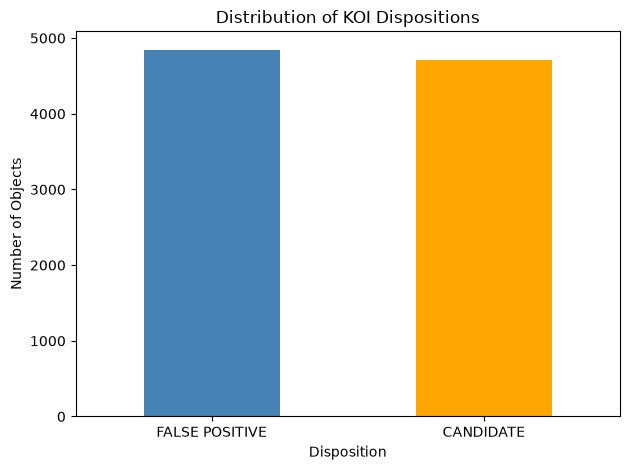

In [16]:
df["koi_pdisposition"].value_counts().plot(kind="bar", color=["steelblue", "orange"])
plt.title("Distribution of KOI Dispositions")
plt.xlabel("Disposition")
plt.ylabel("Number of Objects")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

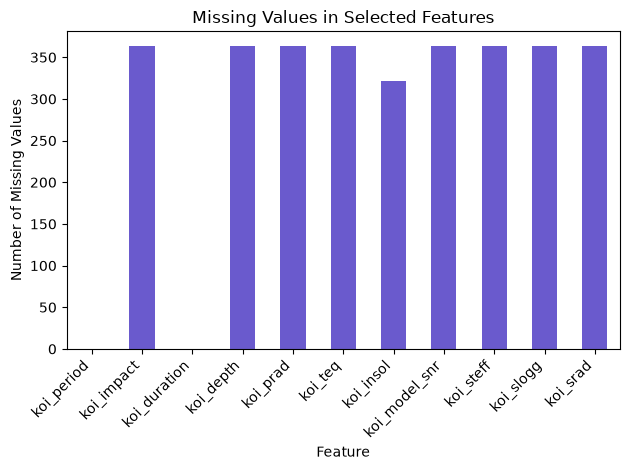

In [17]:
missing_values[features].plot(kind="bar",color="slateblue")
plt.title("Missing Values in Selected Features")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

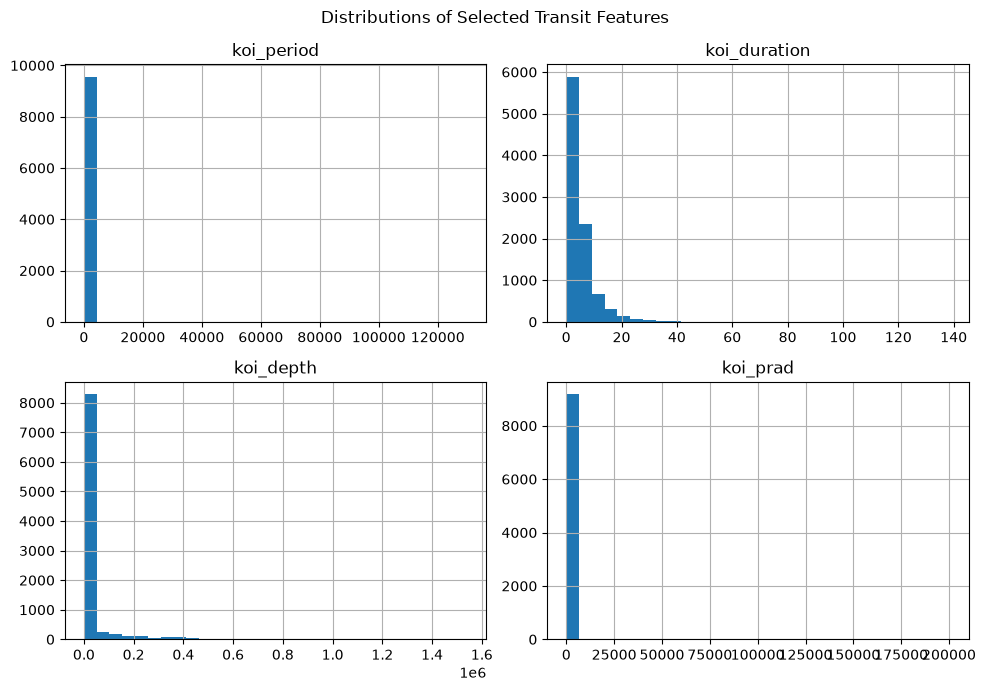

In [18]:
features_to_plot = ["koi_period","koi_duration","koi_depth","koi_prad"]
project_data[features_to_plot].hist(bins=30, figsize=(10, 7))
plt.suptitle("Distributions of Selected Transit Features")
plt.tight_layout()
plt.show()

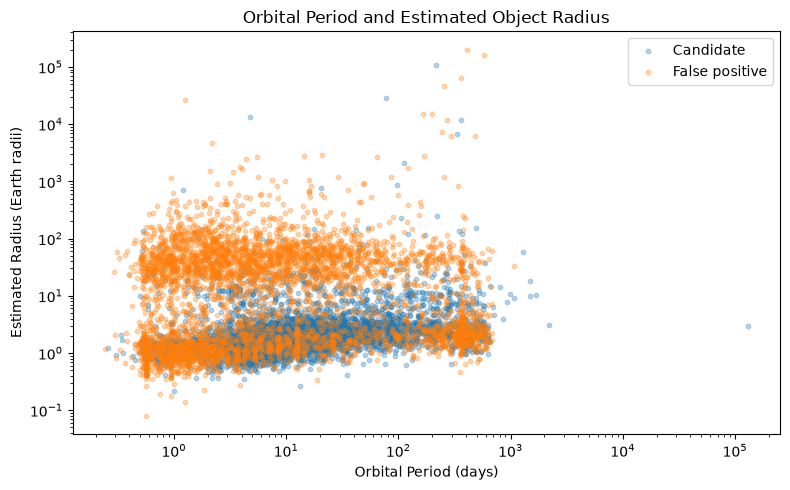

In [19]:
candidate_data = project_data[project_data[target] == "CANDIDATE"]
false_positive_data = project_data[project_data[target] == "FALSE POSITIVE"]
plt.figure(figsize=(8, 5))
plt.scatter(candidate_data["koi_period"],candidate_data["koi_prad"],alpha=0.3,s=10,label="Candidate")
plt.scatter(false_positive_data["koi_period"],false_positive_data["koi_prad"],alpha=0.3,s=10,label="False positive")
plt.xlabel("Orbital Period (days)")
plt.ylabel("Estimated Radius (Earth radii)")
plt.title("Orbital Period and Estimated Object Radius")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import GroupShuffleSplit

X = project_data[features]
y = project_data[target].map({"FALSE POSITIVE": 0,"CANDIDATE": 1})
groups = df["kepid"]
print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (9564, 11)
y shape: (9564,)
koi_pdisposition
0    4847
1    4717
Name: count, dtype: int64


In [21]:
first_split = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_indices, temporary_indices = next(first_split.split(X, y, groups=groups))

In [22]:
X_train = X.iloc[train_indices]
y_train = y.iloc[train_indices]
X_temporary = X.iloc[temporary_indices]
y_temporary = y.iloc[temporary_indices]
temporary_groups = groups.iloc[temporary_indices]

In [23]:
second_split = GroupShuffleSplit(n_splits=1,test_size=0.50,random_state=43)
validation_indices, test_indices = next(second_split.split(X_temporary,y_temporary,groups=temporary_groups))

In [24]:
X_validation = X_temporary.iloc[validation_indices]
y_validation = y_temporary.iloc[validation_indices]
X_test = X_temporary.iloc[test_indices]
y_test = y_temporary.iloc[test_indices]

In [25]:
print("Training set:", len(X_train))
print("Validation set:", len(X_validation))
print("Test set:", len(X_test))

Training set: 6695
Validation set: 1424
Test set: 1445


In [26]:
training_stars = set(groups.iloc[train_indices])
validation_stars = set(temporary_groups.iloc[validation_indices])
test_stars = set(temporary_groups.iloc[test_indices])
print("Stars shared by training and validation:",len(training_stars.intersection(validation_stars)))
print("Stars shared by training and test:",len(training_stars.intersection(test_stars)))
print("Stars shared by validation and test:",len(validation_stars.intersection(test_stars)))

Stars shared by training and validation: 0
Stars shared by training and test: 0
Stars shared by validation and test: 0


In [28]:
logistic_model = Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler()),
    ("classifier",LogisticRegression(max_iter=2000, random_state=42))])
logistic_model.fit(X_train, y_train)
logistic_train_predictions = logistic_model.predict(X_train)
logistic_validation_predictions = logistic_model.predict(X_validation)

In [29]:
# results
logistic_train_accuracy = accuracy_score(y_train,logistic_train_predictions)
logistic_validation_accuracy = accuracy_score(y_validation,logistic_validation_predictions)
logistic_train_error = 1 - logistic_train_accuracy
logistic_validation_error = 1 - logistic_validation_accuracy

print("Logistic Regression")
print("Training accuracy:", logistic_train_accuracy)
print("Validation accuracy:", logistic_validation_accuracy)
print("Training error:", logistic_train_error)
print("Validation error:", logistic_validation_error)

Logistic Regression
Training accuracy: 0.7610156833457804
Validation accuracy: 0.7633426966292135
Training error: 0.2389843166542196
Validation error: 0.2366573033707865


In [31]:
random_forest_model = Pipeline([("imputer",SimpleImputer(strategy="median")),
    ("classifier",RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1))])
random_forest_model.fit(X_train, y_train)
forest_train_predictions = random_forest_model.predict(X_train)
forest_validation_predictions = random_forest_model.predict(X_validation)
   

In [32]:
forest_train_accuracy = accuracy_score(y_train,forest_train_predictions)
forest_validation_accuracy = accuracy_score(y_validation,forest_validation_predictions)
forest_train_error = 1 - forest_train_accuracy
forest_validation_error = 1 - forest_validation_accuracy

print("Random Forest")
print("Training accuracy:", forest_train_accuracy)
print("Validation accuracy:", forest_validation_accuracy)
print("Training error:", forest_train_error)
print("Validation error:", forest_validation_error)

Random Forest
Training accuracy: 1.0
Validation accuracy: 0.8335674157303371
Training error: 0.0
Validation error: 0.1664325842696629


In [42]:
results = pd.DataFrame({"Method": ["Logistic Regression","Random Forest"],
    "Training accuracy": [logistic_train_accuracy,forest_train_accuracy],
    "Validation accuracy": [logistic_validation_accuracy,forest_validation_accuracy],
    "Training error": [logistic_train_error,forest_train_error],
    "Validation error": [logistic_validation_error,forest_validation_error]})
results.round(4)

,Method,Training accuracy,Validation accuracy,Training error,Validation error
0,Logistic Regression,0.761,0.7633,0.239,0.2367
1,Random Forest,1.000,0.8336,0.000,0.1664


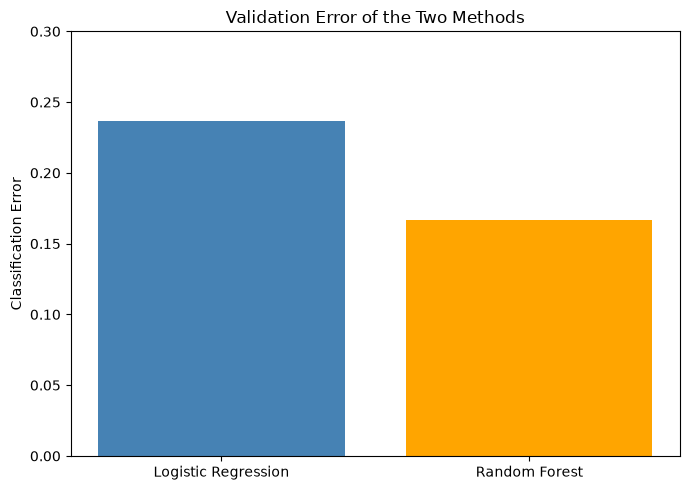

In [35]:
# errors
plt.figure(figsize=(7, 5))
plt.bar(results["Method"],results["Validation error"],color=["steelblue", "orange"])
plt.title("Validation Error of the Two Methods")
plt.ylabel("Classification Error")
plt.ylim(0, 0.30)
plt.tight_layout()
plt.show()

In [36]:
if forest_validation_error < logistic_validation_error:
    final_model = random_forest_model
    final_model_name = "Random Forest"
else:
    final_model = logistic_model
    final_model_name = "Logistic Regression"

print("Selected final model:", final_model_name)

Selected final model: Random Forest


In [37]:
test_predictions = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test,test_predictions)
test_error = 1 - test_accuracy

print("Final model:", final_model_name)
print("Test accuracy:", test_accuracy)
print("Test error:", test_error)

Final model: Random Forest
Test accuracy: 0.8041522491349481
Test error: 0.1958477508650519


In [38]:
print(classification_report(y_test,test_predictions,target_names=["False Positive","Candidate"]))

                precision    recall  f1-score   support

False Positive       0.83      0.78      0.80       742
     Candidate       0.78      0.83      0.80       703

      accuracy                           0.80      1445
     macro avg       0.80      0.80      0.80      1445
  weighted avg       0.81      0.80      0.80      1445



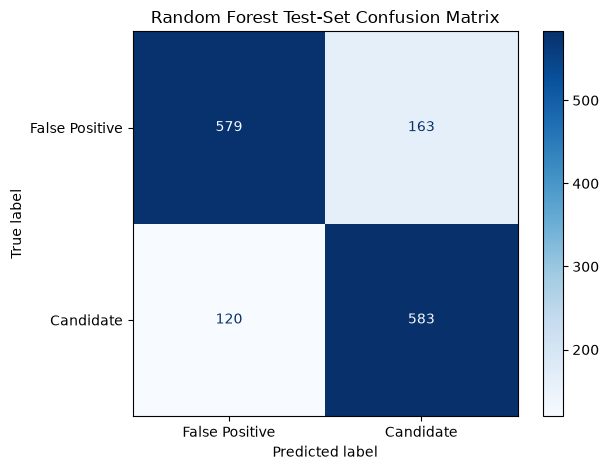

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test,test_predictions,display_labels=["False Positive","Candidate"],cmap="Blues")
plt.title("Random Forest Test-Set Confusion Matrix")
plt.tight_layout()
plt.show()

In [40]:
forest_classifier = random_forest_model.named_steps["classifier"]
feature_importance = pd.DataFrame({"Feature": features,"Importance": forest_classifier.feature_importances_})
feature_importance = feature_importance.sort_values("Importance",ascending=False)
feature_importance

,Feature,Importance
4,koi_prad,0.168839
0,koi_period,0.120175
2,koi_duration,0.106771
3,koi_depth,0.101833
6,koi_insol,0.097507
7,koi_model_snr,0.090221
1,koi_impact,0.086851
5,koi_teq,0.079026
8,koi_steff,0.051488
10,koi_srad,0.049115


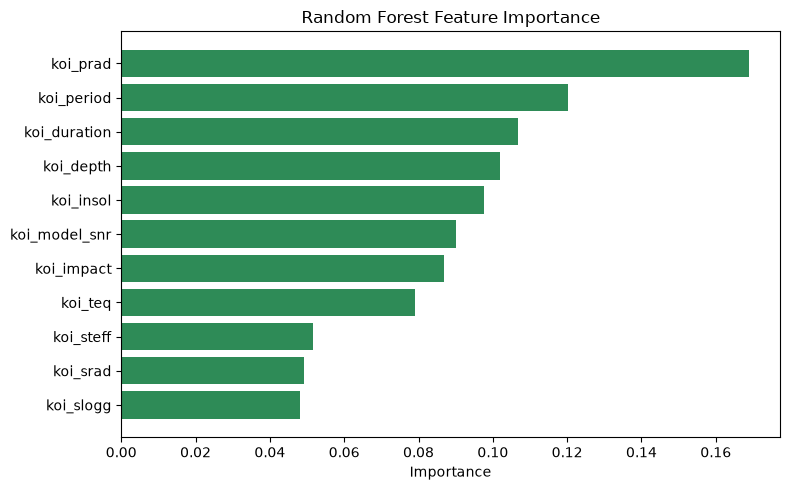

In [41]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"],feature_importance["Importance"],color="seagreen")
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()